# Stochastic Models Verification

In this notebook, we verify the implementation of the new stochastic models for interest rates, which include:
- Time-Varying Hull-White (1-Factor and 2-Factor) models
- Shifted-CIR model
- Shifted-Lognormal model

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from src.models.stochastic import (
    HullWhite1FModel,
    HullWhite2FModel,
    ShiftedCIRModel,
    ShiftedLognormalModel,
)
from src.models.monte_carlo import MonteCarloEngine

# Formatting for plots
plt.style.use("seaborn-v0_8-darkgrid")

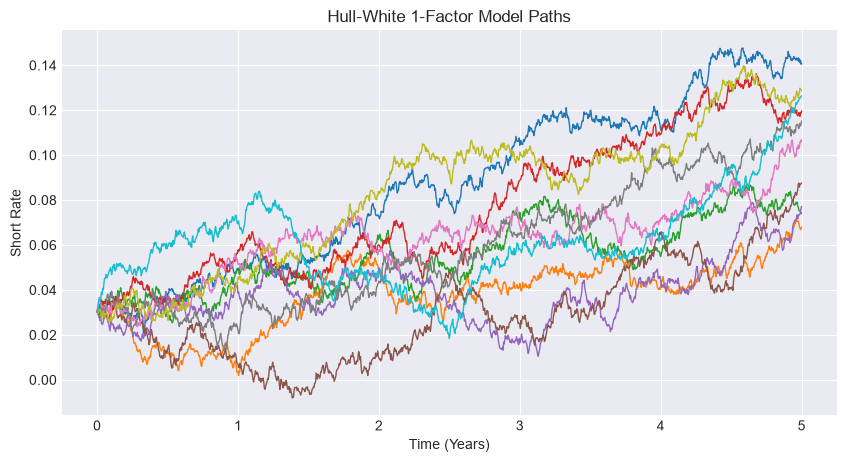

In [2]:
# 1. Hull-White 1-Factor Model
a = 0.1
sigma = 0.02


def theta(t):
    return 0.01 + 0.005 * t


r0 = 0.03
T = 5.0

hw1f = HullWhite1FModel(a, sigma, theta)
mc_hw1f = MonteCarloEngine(hw1f, n_paths=100, n_steps=252 * 5, seed=42)

paths_hw1f = mc_hw1f.simulate_paths(r0, T)
time_grid = np.linspace(0, T, mc_hw1f.n_steps + 1)

plt.figure(figsize=(10, 5))
plt.plot(time_grid, paths_hw1f[:, :10], lw=1)
plt.title("Hull-White 1-Factor Model Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.show()

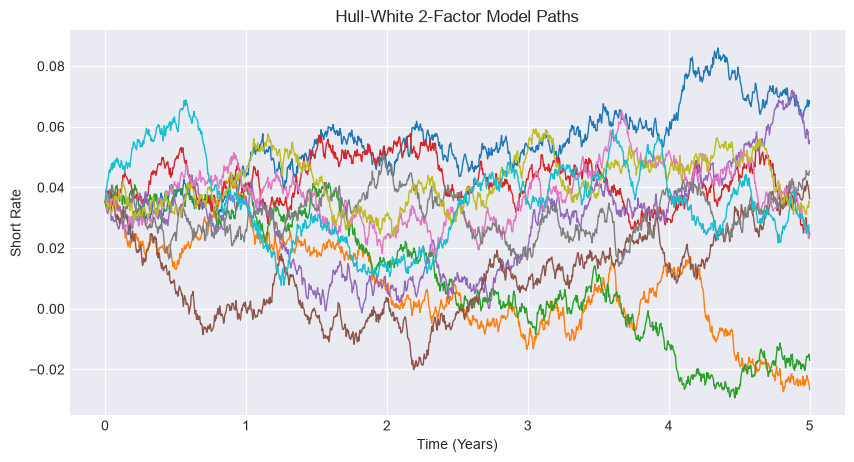

In [3]:
# 2. Hull-White 2-Factor Model
a, b = 0.1, 0.2
sigma1, sigma2 = 0.02, 0.01
rho = -0.3


def phi(t):
    return 0.02


x0, y0 = 0.01, 0.005
r0_hw2f = (x0, y0)

hw2f = HullWhite2FModel(a, b, sigma1, sigma2, rho, phi)
mc_hw2f = MonteCarloEngine(hw2f, n_paths=100, n_steps=252 * 5, seed=42)

paths_hw2f = mc_hw2f.simulate_paths(r0_hw2f, T)

plt.figure(figsize=(10, 5))
plt.plot(time_grid, paths_hw2f[:, :10], lw=1)
plt.title("Hull-White 2-Factor Model Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.show()

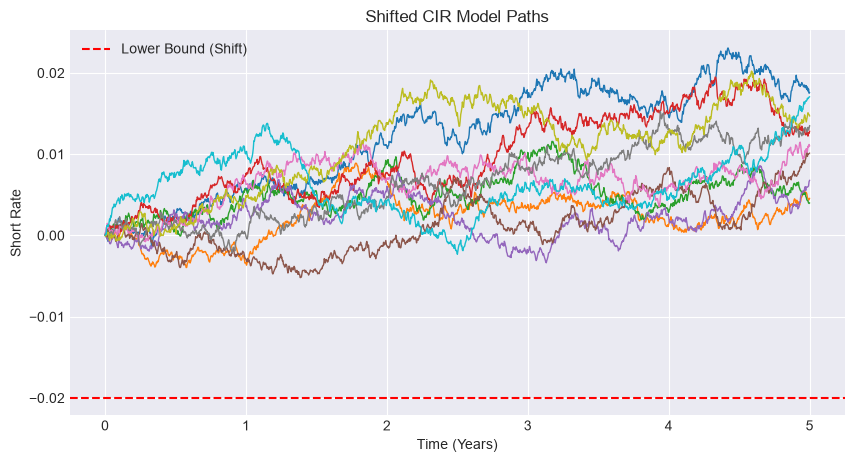

In [4]:
# 3. Shifted CIR Model
a, b, sigma, shift = 0.2, 0.04, 0.03, -0.02
r0 = 0.00

shifted_cir = ShiftedCIRModel(a, b, sigma, shift)
mc_scir = MonteCarloEngine(shifted_cir, n_paths=100, n_steps=252 * 5, seed=42)

paths_scir = mc_scir.simulate_paths(r0, T)

plt.figure(figsize=(10, 5))
plt.plot(time_grid, paths_scir[:, :10], lw=1)
plt.axhline(shift, color="red", linestyle="--", label="Lower Bound (Shift)")
plt.title("Shifted CIR Model Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.show()

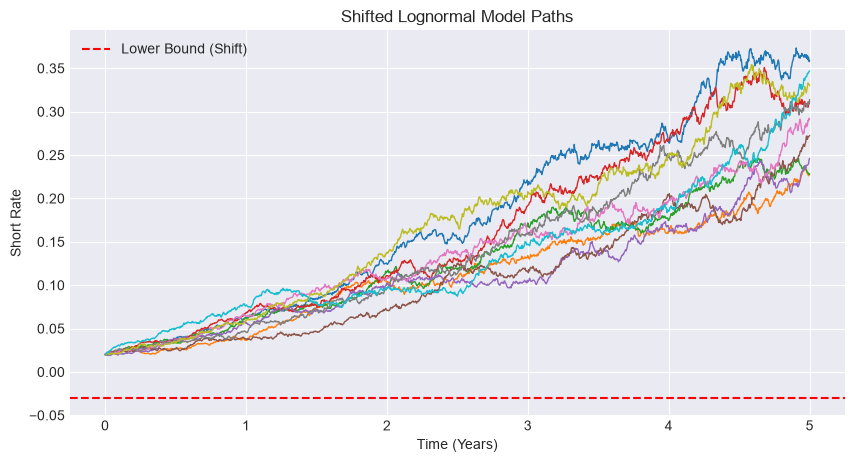

In [5]:
# 4. Shifted Lognormal Model
a, theta_sl, sigma, shift = 0.2, 0.01, 0.15, -0.03
r0 = 0.02

shifted_lognorm = ShiftedLognormalModel(a, theta_sl, sigma, shift)
mc_sln = MonteCarloEngine(shifted_lognorm, n_paths=100, n_steps=252 * 5, seed=42)

paths_sln = mc_sln.simulate_paths(r0, T)

plt.figure(figsize=(10, 5))
plt.plot(time_grid, paths_sln[:, :10], lw=1)
plt.axhline(shift, color="red", linestyle="--", label="Lower Bound (Shift)")
plt.title("Shifted Lognormal Model Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.show()

In [6]:
# 5. Zero-Coupon Bond Pricing Comparison
T_pricing = 2.0
print(f"Pricing 2-year ZCB:\n")

hw1f_price = hw1f.zcb_price(r0, 0.0, T_pricing)
print(f"HW1F Analytic Price: {hw1f_price:.6f}")

hw2f_price = hw2f.zcb_price(x0, y0, 0.0, T_pricing)
print(f"HW2F Analytic Price: {hw2f_price:.6f}")

scir_price = shifted_cir.zcb_price(r0, T_pricing)
print(f"Shifted CIR Analytic Price: {scir_price:.6f}")

mc_sln_price = mc_sln.price_zcb(r0, T_pricing)
print(f"Shifted Lognormal MC Price: {mc_sln_price:.6f}")

Pricing 2-year ZCB:

HW1F Analytic Price: 0.940945
HW2F Analytic Price: 0.936189
Shifted CIR Analytic Price: 0.960824
Shifted Lognormal MC Price: 0.888555
